# Validación de Fotometría

Esta libreta verifica el módulo de fotometría paso a paso:
1. Resolución automática del objetivo (WCS con astrometry.net)
2. Detección de fuentes y selección de comparadoras
3. Inspección visual de aperturas sobre el frame de referencia
4. Ejecución del pipeline completo y visualización de la curva de luz diferencial
5. Normalización y de-trending

In [1]:
from pathlib import Path
import sys
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# --- Carga de variables de entorno desde .env ---
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    # Fallback sin python-dotenv: leer .env manualmente
    _env_file = Path.cwd().resolve().parent / '.env' if Path.cwd().name == 'notebooks' else Path.cwd() / '.env'
    if _env_file.exists():
        for _line in _env_file.read_text().splitlines():
            _line = _line.strip()
            if _line and not _line.startswith('#') and '=' in _line:
                _k, _v = _line.split('=', 1)
                os.environ.setdefault(_k.strip(), _v.strip())

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ALIGNED_DIR  = PROJECT_ROOT / 'data' / 'aligned'
PHOT_DIR     = PROJECT_ROOT / 'data' / 'photometry'


In [3]:
REF_FRAME    = next(ALIGNED_DIR.glob('ali_*003.fit'))

api_key_ok = bool(os.environ.get("ASTROMETRY_NET_API_KEY"))
print(f"Frame de referencia : {REF_FRAME.name}")
print(f"Salida fotometría   : {PHOT_DIR}")
print(f"API key cargada     : {'OK' if api_key_ok else 'NO ENCONTRADA — revisa el .env'}")

Frame de referencia : ali_cal_wasp-2-003.fit
Salida fotometría   : C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\data\photometry
API key cargada     : OK


## 1 · Plate scale automático y posición del objetivo

Usa los metadatos del FITS (XPIXSZ, FOCALLEN, XBINNING) para calcular el plate scale
y usa el WCS solver para encontrar las sources

In [5]:
import photometry.io as phot_io
importlib.reload(phot_io)

from astropy.io import fits
header = fits.getheader(REF_FRAME)
"""
plate_scale = phot_io.estimate_pixel_scale_arcsec(header)
print(f"XPIXSZ     : {header.get('XPIXSZ')} µm")
print(f"FOCALLEN   : {header.get('FOCALLEN')} mm")
print(f"XBINNING   : {header.get('XBINNING')}")
print(f"Plate scale: {plate_scale:.3f} arcsec/px")
"""
OBJECT_NAME = 'wasp-2'
target_x, target_y = phot_io.resolve_target_xy(
    REF_FRAME,
    OBJECT_NAME,
    wcs_solver="online",      # API key se lee automáticamente desde os.environ
    persist_solved_wcs=True,  # cachea el WCS resuelto → frames siguientes son instantáneos
)
print(f"\nPosición de {OBJECT_NAME}: x={target_x:.1f} px, y={target_y:.1f} px")
print(f"Tamaño del frame   : {header['NAXIS1']} × {header['NAXIS2']} px")


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Determining background stats


Finding sources
Found 216 sources
 id     xcentroid      ...         mag              daofind_mag     
--- ------------------ ... ------------------- ---------------------
 31  895.8039460618801 ... -15.284205673882784    -5.572026514641849
 33  898.5060624859307 ... -15.217879975398933    -5.725959696292949
 35  894.9370950298307 ... -15.096367154663158    -5.818661297049413
  9 448.69316360071565 ... -14.586868423326539    -5.433817342786435
 79  92.00931471900903 ... -13.896383457100516    -5.208923357161841
154 241.89354388986234 ...   -13.4569290297354    -4.924590465343408
 24  236.8202627254626 ... -13.254727503558293    -4.231497210126808
 93  851.3226875831866 ... -13.082882548644811    -3.927404338456335
174 162.69415907060971 ... -13.075048889799113    -4.595124016560253
 67  575.3851367507095 ... -13.021310198461705    -4.005487365838526
...                ... ...                 ...                   ...
157  400.8571861219103 ...  -8.180091606650647  -0.07533525202355879


## 2 · Detección de fuentes en el frame de referencia

Muestra las estrellas detectadas, marcando el objetivo y las comparadoras elegidas.

In [6]:
import photometry.aperture as phot_ap
importlib.reload(phot_ap)
import reduction.io as reduction_io
importlib.reload(reduction_io)
from astropy.visualization import ZScaleInterval

from photometry.pipeline import PhotometryConfig

config = PhotometryConfig(
    object_name=OBJECT_NAME,
    detection_fwhm=3.5,
    detection_threshold_sigma=5.0,   # umbral bajo para detectar Qatar-1 (V~12.8)
    max_comparisons=5,
    min_neighbor_distance=0.0,
    comparison_brightness_range=(0.2, 5.0),
)

ref_ccd = reduction_io.load_ccd(str(REF_FRAME))
sources = phot_ap.detect_sources(
    ref_ccd.data,
    fwhm=config.detection_fwhm,
    threshold_sigma=config.detection_threshold_sigma,
    exclude_border=config.exclude_border,
    brightest=config.brightest_sources,
)
target_source = phot_ap.choose_target_source(
    sources,
    image_shape=ref_ccd.data.shape,
    target_xy=(target_x, target_y),
)

snap_dist = float(np.hypot(target_source['x'] - target_x, target_source['y'] - target_y))
print(f"Fuentes detectadas        : {len(sources)}")
print(f"Posición WCS              : ({target_x:.1f}, {target_y:.1f}) px")
print(f"Snap → fuente más cercana : ({target_source['x']:.1f}, {target_source['y']:.1f}) px")
print(f"Distancia de snap         : {snap_dist:.1f} px  ({'OK' if snap_dist < 3*config.detection_fwhm else 'ALERTA: puede no ser Qatar-1'})")

fwhm_est   = config.detection_fwhm
ap_r_est   = max(config.aperture_scale * fwhm_est, 2.0)
ann_r2_est = max(config.annulus_scale_outer * ap_r_est, ap_r_est + 2.0)
effective_min_sep = ann_r2_est + 5.0
min_neighbor_distance = ann_r2_est + ap_r_est + 2.0

comparison_sources = phot_ap.choose_comparison_sources(
    sources,
    target_source=target_source,
    image_shape=ref_ccd.data.shape,
    max_comparisons=config.max_comparisons,
    min_separation=effective_min_sep,
    min_edge_distance=config.min_edge_distance,
)
print(f"Separación mínima al objetivo : {effective_min_sep:.1f} px")
print(f"Aislamiento mínimo a vecinas  : {min_neighbor_distance:.1f} px")
print(f"Comparadoras seleccionadas    : {len(comparison_sources)}")

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Fuentes detectadas        : 194
Posición WCS              : (575.2, 404.1) px
Snap → fuente más cercana : (575.4, 403.4) px
Distancia de snap         : 0.7 px  (OK)
Separación mínima al objetivo : 26.0 px
Aislamiento mínimo a vecinas  : 31.8 px
Comparadoras seleccionadas    : 5


## 3 · Inspección visual de aperturas

Muestra el frame de referencia con los círculos de apertura y anillo de fondo para el objetivo
y las comparadoras. Verde = objetivo, naranja = comparadoras, anillos en azul claro.

coincida con el método usado durante la fotometría por frame.
Shift de recentrado (objetivo): 0.73 px
Shift medio comparadoras      : 0.67 px
Distancia snap (WCS->centro)  : 1.44 px
FWHM base      : 3.50 px
Apertura       : 8.75 px
Anillo interno : 14.88 px
Anillo externo : 21.00 px


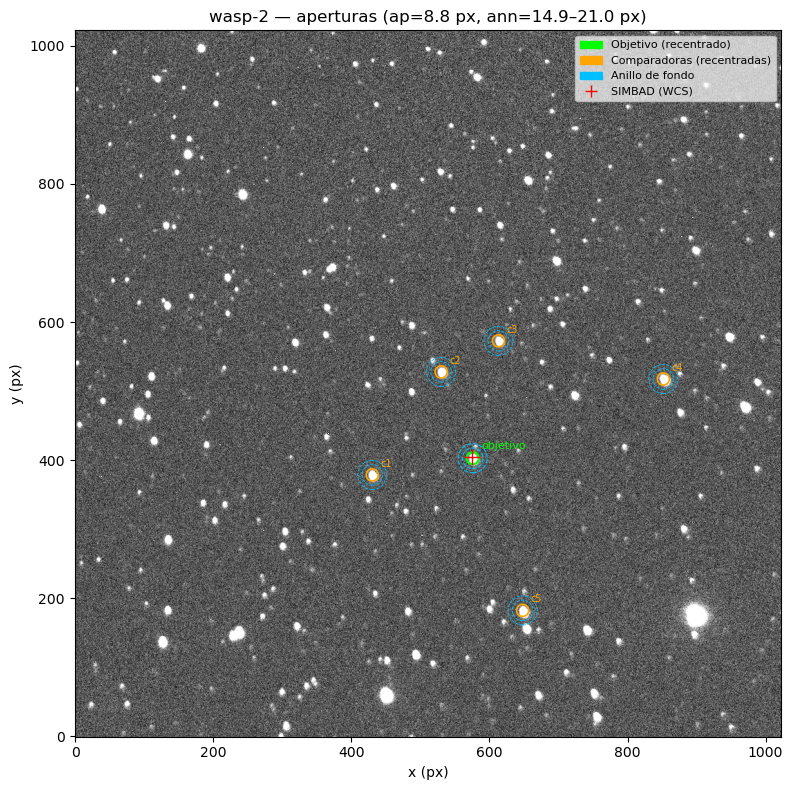

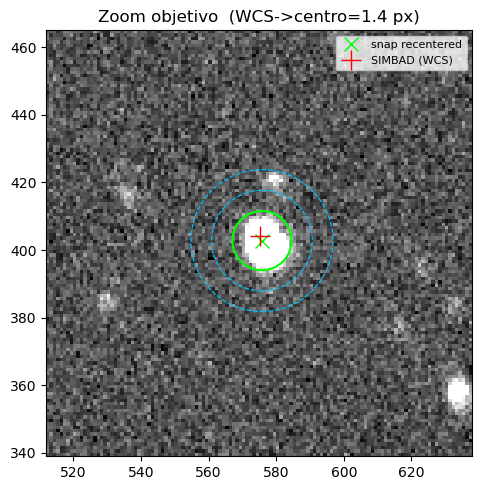

In [7]:
from numpy import median as np_median
import photometry.pipeline as phot_pipeline
importlib.reload(phot_pipeline)

# Recentrar posiciones en el frame de referencia para que la inspección visual
print("coincida con el método usado durante la fotometría por frame.")
target_x_ref, target_y_ref = phot_pipeline._recenter_position(
    ref_ccd.data,
    x=float(target_source["x"]),
    y=float(target_source["y"]),
    box_size=config.centroid_box_size,
)
target_source_plot = {**target_source, "x": target_x_ref, "y": target_y_ref}

comparison_sources_plot: list[dict[str, float]] = []
comparison_shifts: list[float] = []
for source in comparison_sources:
    sx_ref, sy_ref = phot_pipeline._recenter_position(
        ref_ccd.data,
        x=float(source["x"]),
        y=float(source["y"]),
        box_size=config.centroid_box_size,
    )
    comparison_sources_plot.append({**source, "x": sx_ref, "y": sy_ref})
    comparison_shifts.append(float(np.hypot(sx_ref - source["x"], sy_ref - source["y"])))

target_shift = float(np.hypot(
    target_source_plot["x"] - target_source["x"],
    target_source_plot["y"] - target_source["y"],
))
snap_dist_plot = float(np.hypot(target_source_plot['x'] - target_x, target_source_plot['y'] - target_y))
print(f"Shift de recentrado (objetivo): {target_shift:.2f} px")
if comparison_shifts:
    print(f"Shift medio comparadoras      : {np.mean(comparison_shifts):.2f} px")
print(f"Distancia snap (WCS->centro)  : {snap_dist_plot:.2f} px")

# Calcular radios de apertura
fwhm_samples = [target_source_plot.get('fwhm', config.detection_fwhm)]
fwhm_samples += [s.get('fwhm', config.detection_fwhm) for s in comparison_sources_plot]
base_fwhm = float(np_median(fwhm_samples))
ap_r   = max(config.aperture_scale * base_fwhm, 2.0)
ann_r1 = max(config.annulus_scale_inner * ap_r, ap_r + 2.0)
ann_r2 = max(config.annulus_scale_outer * ap_r, ann_r1 + 2.0)

print(f"FWHM base      : {base_fwhm:.2f} px")
print(f"Apertura       : {ap_r:.2f} px")
print(f"Anillo interno : {ann_r1:.2f} px")
print(f"Anillo externo : {ann_r2:.2f} px")

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(ref_ccd.data)

# --- Vista global con aperturas ---
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(ref_ccd.data, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

for r, color, lw, ls in [(ap_r, 'lime', 1.5, '-'), (ann_r1, 'deepskyblue', 0.8, '--'), (ann_r2, 'deepskyblue', 0.8, '--')]:
    ax.add_patch(plt.Circle((target_source_plot['x'], target_source_plot['y']), r, color=color, fill=False, lw=lw, ls=ls))
ax.annotate('objetivo', xy=(target_source_plot['x'], target_source_plot['y']),
            xytext=(target_source_plot['x'] + ap_r + 4, target_source_plot['y'] + ap_r + 4),
            color='lime', fontsize=8, ha='left')

for i, c in enumerate(comparison_sources_plot, 1):
    for r, color, lw, ls in [(ap_r, 'orange', 1.2, '-'), (ann_r1, 'deepskyblue', 0.6, '--'), (ann_r2, 'deepskyblue', 0.6, '--')]:
        ax.add_patch(plt.Circle((c['x'], c['y']), r, color=color, fill=False, lw=lw, ls=ls))
    ax.annotate(f'c{i}', xy=(c['x'], c['y']),
                xytext=(c['x'] + ap_r + 3, c['y'] + ap_r + 3),
                color='orange', fontsize=7, ha='left')

ax.plot(target_x, target_y, '+', color='red', ms=12, lw=1.5)
legend_handles = [
    mpatches.Patch(color='lime',        label='Objetivo (recentrado)'),
    mpatches.Patch(color='orange',      label='Comparadoras (recentradas)'),
    mpatches.Patch(color='deepskyblue', label='Anillo de fondo'),
    plt.Line2D([0], [0], marker='+', color='red', linestyle='None', ms=8, label='SIMBAD (WCS)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8, framealpha=0.7)
ax.set_title(f'{OBJECT_NAME} — aperturas (ap={ap_r:.1f} px, ann={ann_r1:.1f}–{ann_r2:.1f} px)')
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
plt.tight_layout()
plt.show()

# --- Zoom en la región del objetivo ---
ZOOM_R = max(int(ann_r2 * 3), 60)
tx, ty = int(target_source_plot['x']), int(target_source_plot['y'])
x0, x1 = max(tx - ZOOM_R, 0), min(tx + ZOOM_R, ref_ccd.data.shape[1])
y0, y1 = max(ty - ZOOM_R, 0), min(ty + ZOOM_R, ref_ccd.data.shape[0])

crop = ref_ccd.data[y0:y1, x0:x1]
vmin_z, vmax_z = zscale.get_limits(crop)

fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.imshow(crop, cmap='gray', vmin=vmin_z, vmax=vmax_z, origin='lower', extent=[x0, x1, y0, y1])
for r, color, lw, ls in [(ap_r, 'lime', 1.5, '-'), (ann_r1, 'deepskyblue', 0.9, '--'), (ann_r2, 'deepskyblue', 0.9, '--')]:
    ax2.add_patch(plt.Circle((target_source_plot['x'], target_source_plot['y']), r, color=color, fill=False, lw=lw, ls=ls))
ax2.plot(target_source_plot['x'], target_source_plot['y'], 'x', color='lime', ms=10, lw=1.5, label='snap recentered')
ax2.plot(target_x, target_y, '+', color='red', ms=14, lw=1.5, label='SIMBAD (WCS)')
ax2.set_title(f'Zoom objetivo  (WCS->centro={snap_dist_plot:.1f} px)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4 · Ejecución del pipeline completo

Genera `source_catalog.csv`, `aperture_photometry.csv` y `differential_light_curve.csv`.
Solo es necesario ejecutar esta celda una vez; las siguientes leen los CSV.

In [ ]:
import photometry.pipeline as phot_pipeline
importlib.reload(phot_pipeline)
from photometry.pipeline import PhotometryPaths, PhotometryConfig, run_photometry_pipeline

phot_paths = PhotometryPaths(
    aligned_dir=ALIGNED_DIR,
    output_dir=PHOT_DIR,
)
phot_config = PhotometryConfig(
    object_name=OBJECT_NAME,
    max_comparisons=5,
    wcs_solver="online",      # API key desde os.environ (cargada en celda 1)
    persist_solved_wcs=True,
    comparison_brightness_range=(0.2, 5.0),
    min_neighbor_distance=0.0,
)

light_curve_table = run_photometry_pipeline(phot_paths, phot_config)
print(f"Puntos de curva de luz: {len(light_curve_table)}")
print(light_curve_table[:5])

## 4b · Optimización automática de parámetros fotométricos

Busca automáticamente la mejor combinación de número de comparadoras, FWHM de detección y escala de apertura minimizando el RMS OOT.

Nota: esta celda reejecuta varias veces el pipeline y sobrescribe temporalmente los CSV en `data/photometry` durante la búsqueda.

In [ ]:
import dataclasses
from itertools import product

# Reutiliza la función del pipeline para puntuar con RMS OOT de forma consistente
score_rms_oot = phot_pipeline._compute_rms_oot

comparisons_grid = [3, 4, 5, 6, 8, 10]
fwhm_grid = [3.0, 3.5, 4.0, 4.5]
aperture_scale_grid = [1.6, 1.8, 2.0, 2.2, 2.5]

print("Buscando mejor configuración... (puede tardar unos minutos)")
search_rows = []

for n_comp, det_fwhm, ap_scale in product(comparisons_grid, fwhm_grid, aperture_scale_grid):
    trial_cfg = dataclasses.replace(
        phot_config,
        max_comparisons=int(n_comp),
        detection_fwhm=float(det_fwhm),
        aperture_scale=float(ap_scale),
    )

    try:
        _ = run_photometry_pipeline(phot_paths, trial_cfg)
        trial_lc = pd.read_csv(PHOT_DIR / 'differential_light_curve.csv')
        trial_rms_oot = score_rms_oot(
            trial_lc,
            baseline_percentile_range=trial_cfg.oot_baseline_percentile_range,
            transit_threshold_sigma=trial_cfg.oot_transit_threshold_sigma,
        )
        trial_rms_total = float(trial_lc['relative_flux'].std()) if not trial_lc.empty else np.nan
        search_rows.append({
            'max_comparisons': int(n_comp),
            'detection_fwhm': float(det_fwhm),
            'aperture_scale': float(ap_scale),
            'rms_oot_mmag': float(trial_rms_oot * 1000.0) if trial_rms_oot is not None else np.nan,
            'rms_total_mmag': float(trial_rms_total * 1000.0) if np.isfinite(trial_rms_total) else np.nan,
            'n_points': int(len(trial_lc)),
            'status': 'ok',
        })
    except Exception as exc:
        search_rows.append({
            'max_comparisons': int(n_comp),
            'detection_fwhm': float(det_fwhm),
            'aperture_scale': float(ap_scale),
            'rms_oot_mmag': np.nan,
            'rms_total_mmag': np.nan,
            'n_points': 0,
            'status': f'error: {exc}',
        })

search_df = pd.DataFrame(search_rows)
valid_df = search_df[(search_df['status'] == 'ok') & search_df['rms_oot_mmag'].notna()].copy()

if valid_df.empty:
    raise RuntimeError('No se encontró ninguna combinación válida en la rejilla.')

valid_df = valid_df.sort_values(['rms_oot_mmag', 'rms_total_mmag']).reset_index(drop=True)
best_row = valid_df.iloc[0]

print("\nTop 10 combinaciones por RMS OOT:")
print(valid_df.head(10).to_string(index=False, formatters={
    'rms_oot_mmag': '{:.3f}'.format,
    'rms_total_mmag': '{:.3f}'.format,
}))

best_config = dataclasses.replace(
    phot_config,
    max_comparisons=int(best_row['max_comparisons']),
    detection_fwhm=float(best_row['detection_fwhm']),
    aperture_scale=float(best_row['aperture_scale']),
)

print("\nMejor configuración encontrada:")
print(f"  max_comparisons : {best_config.max_comparisons}")
print(f"  detection_fwhm  : {best_config.detection_fwhm:.2f}")
print(f"  aperture_scale  : {best_config.aperture_scale:.2f}")
print(f"  RMS OOT         : {best_row['rms_oot_mmag']:.3f} mmag")
print(f"  RMS total       : {best_row['rms_total_mmag']:.3f} mmag")

# Aplicar la mejor configuración para dejar listos los CSV de las celdas siguientes
phot_config = best_config
light_curve_table = run_photometry_pipeline(phot_paths, phot_config)
print(f"\nPipeline reejecutado con la mejor configuración. Puntos: {len(light_curve_table)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(valid_df['max_comparisons'], valid_df['rms_oot_mmag'], 'o', alpha=0.65)
ax.set_xlabel('Número de comparadoras')
ax.set_ylabel('RMS OOT (mmag)')
ax.set_title('Búsqueda automática: RMS OOT vs número de comparadoras')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

valid_df.head(15)

## 5 · Curva de luz diferencial

Flujo relativo normalizado a la mediana. Un tránsito aparece como un descenso por debajo de 1.

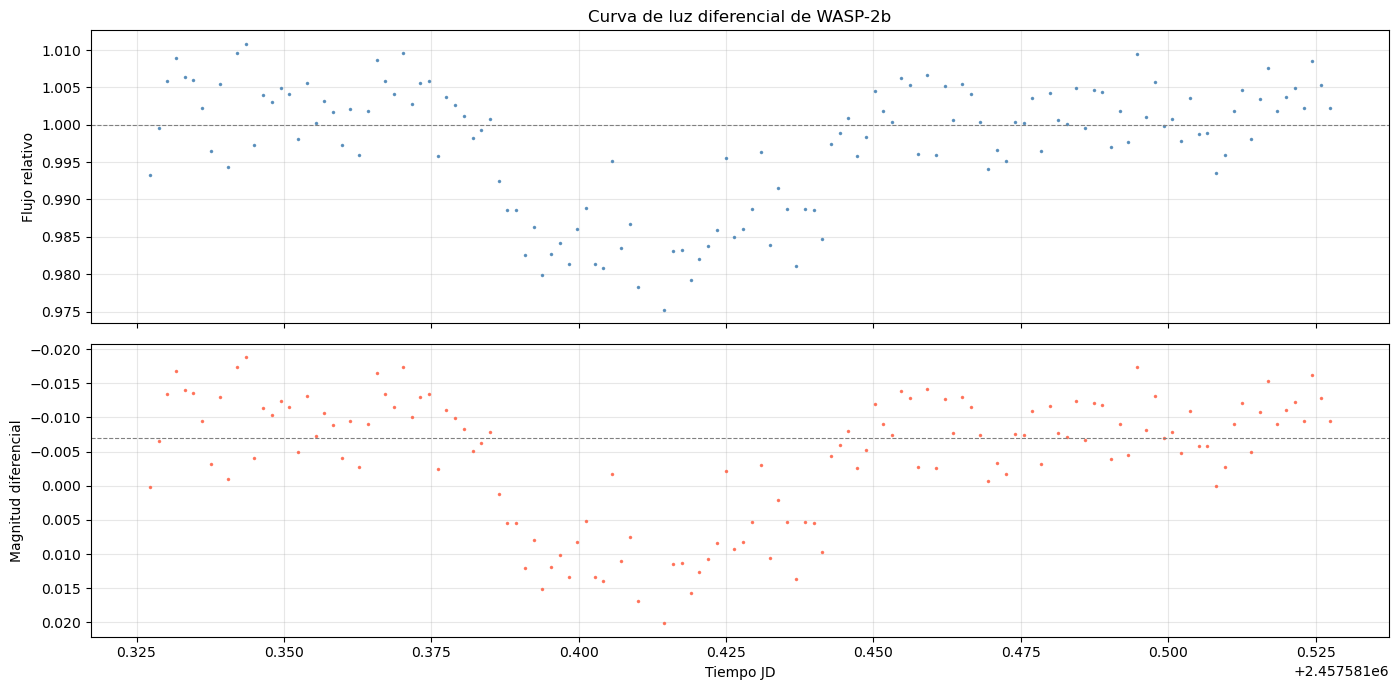

RMS del flujo relativo : 8.43 mmag
Puntos totales         : 134
Comparadoras usadas    : 4


In [10]:

lc = pd.read_csv(PHOT_DIR / 'differential_light_curve.csv')

time_col = 'time_jd' if 'time_jd' in lc.columns and lc['time_jd'].notna().any() else 'frame_index'
x_label  = 'Tiempo JD' if time_col == 'time_jd' else 'Índice de frame'

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(lc[time_col], lc['relative_flux'], '.', color='steelblue', ms=3, alpha=0.8)
axes[0].axhline(1.0, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('Flujo relativo')
axes[0].set_title(f'Curva de luz diferencial de WASP-2b')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lc[time_col], lc['differential_mag'], '.', color='tomato', ms=3, alpha=0.8)
axes[1].axhline(lc['differential_mag'].median(), color='gray', lw=0.8, linestyle='--')
axes[1].invert_yaxis()
axes[1].set_ylabel('Magnitud diferencial')
axes[1].set_xlabel(x_label)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rms = float(lc['relative_flux'].std())
print(f"RMS del flujo relativo : {rms*1000:.2f} mmag")
print(f"Puntos totales         : {len(lc)}")
print(f"Comparadoras usadas    : {int(lc['n_comparisons_used'].mode()[0])}")

## 6 · Normalización y detrending

Paso crítico antes de ajuste de tránsito:
1. **Normalización**: escala flujo relativo a 1.0 usando baseline pre-tránsito (primeros ~20-30% de datos)
2. **Máscara de tránsito completa**: detecta el núcleo y expande la ventana para cubrir ingreso, fondo y egreso
3. **Detrending polinomial**: remueve tendencias (airmass, FWHM, time-dependence) ajustando solo OOT

Resultado: curva limpia lista para caracterización del tránsito

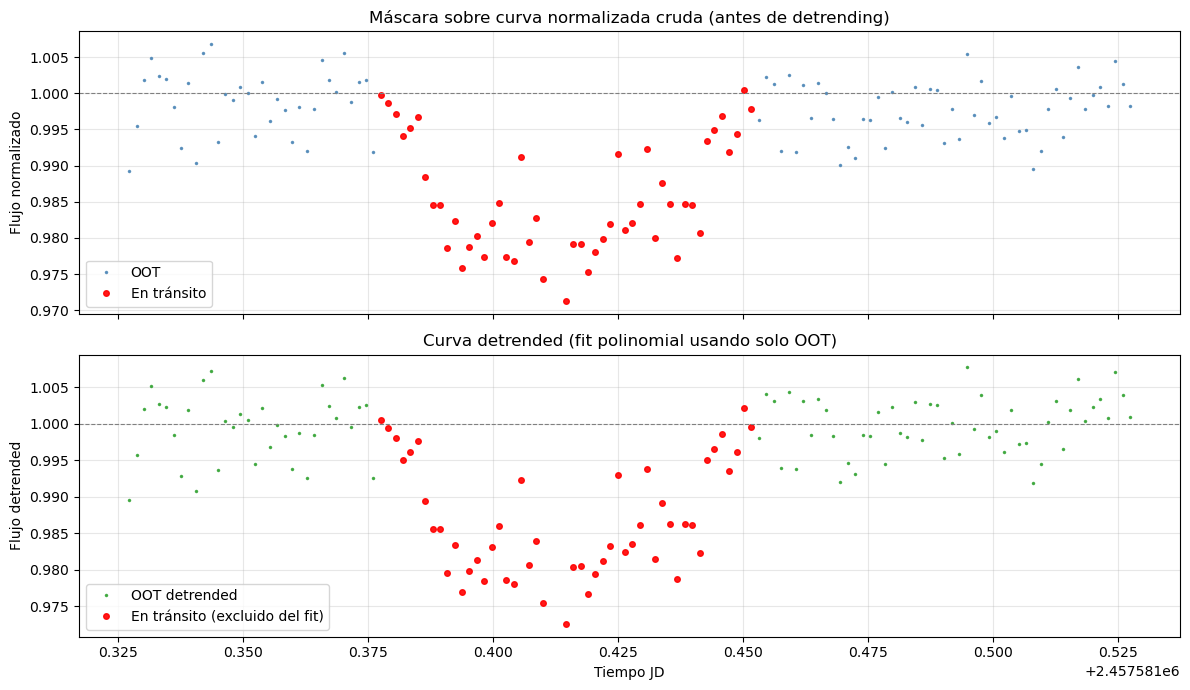

Puntos en tránsito: 49 / 134
RMS OOT normalizado (crudo): 4.207 mmag
RMS OOT detrended (final) : 4.200 mmag
Curva final en memoria: lc_detrended (lista para exportar a differential_light_curve_detrended_masked.csv)


In [11]:
# Flujo correcto: cruda -> normalizar -> máscara -> detrending OOT -> curva final
import photometry.detrending as phot_detrend
importlib.reload(phot_detrend)

# 0) Cargar curva cruda (sin detrending previo)
lc_raw = pd.read_csv(PHOT_DIR / 'differential_light_curve.csv').copy()

time_col = 'time_jd' if 'time_jd' in lc_raw.columns and lc_raw['time_jd'].notna().any() else 'frame_index'
x_label = 'Tiempo JD' if time_col == 'time_jd' else 'Índice de frame'

# 1) Normalizar sobre baseline inicial (curva cruda)
lc_norm = phot_detrend.normalize_to_baseline(
    lc_raw,
    relative_flux_column='relative_flux',
    baseline_percentile_range=(0.0, 15.0),
)

# 2) Máscara de tránsito desde la curva NORMALIZADA cruda (con suavizado interno + cruces 10% + buffer)
mask_buffer_points = 0
transit_mask = phot_detrend.estimate_transit_mask(
    lc_norm,
    normalized_flux_column='normalized_flux',
    window_buffer_points=mask_buffer_points,
).astype(bool)

lc_norm = lc_norm.copy()
lc_norm['in_transit_mask'] = transit_mask

# 3) Detrending polinomial ajustado SOLO con OOT
if 'best_payload' in locals() and isinstance(best_payload, dict) and 'degree' in best_payload:
    detrend_degree = int(best_payload['degree'])
else:
    detrend_degree = 1

lc_detrended = phot_detrend.detrend_polynomial(
    lc_norm,
    normalized_flux_column='normalized_flux',
    index_column=time_col,
    degree=detrend_degree,
    mask_out_of_transit=True,
    transit_mask_column='in_transit_mask',
    robust=True,
)

# 4) Métricas y visualización
oot_mask = ~transit_mask
resid_norm_oot = (lc_norm.loc[oot_mask, 'normalized_flux'] - 1.0).to_numpy(dtype=float)
resid_det_oot = (lc_detrended.loc[oot_mask, 'detrended_flux'] - 1.0).to_numpy(dtype=float)
rms_norm_oot_mmag = float(np.std(resid_norm_oot, ddof=1) * 1000.0) if oot_mask.sum() > 1 else np.nan
rms_det_oot_mmag = float(np.std(resid_det_oot, ddof=1) * 1000.0) if oot_mask.sum() > 1 else np.nan

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(lc_norm.loc[oot_mask, time_col], lc_norm.loc[oot_mask, 'normalized_flux'], '.', color='steelblue', ms=3, alpha=0.8, label='OOT')
axes[0].plot(
    lc_norm.loc[transit_mask, time_col],
    lc_norm.loc[transit_mask, 'normalized_flux'],
    'o', color='red', ms=4, alpha=0.9, label='En tránsito'
)
axes[0].axhline(1.0, color='gray', lw=0.8, linestyle='--')
axes[0].set_ylabel('Flujo normalizado')
axes[0].set_title('Máscara sobre curva normalizada cruda (antes de detrending)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lc_detrended.loc[oot_mask, time_col], lc_detrended.loc[oot_mask, 'detrended_flux'], '.', color='tab:green', ms=3, alpha=0.8, label='OOT detrended')
axes[1].plot(
    lc_detrended.loc[transit_mask, time_col],
    lc_detrended.loc[transit_mask, 'detrended_flux'],
    'o', color='red', ms=4, alpha=0.9, label='En tránsito (excluido del fit)'
)
axes[1].axhline(1.0, color='gray', lw=0.8, linestyle='--')
axes[1].set_xlabel(x_label)
axes[1].set_ylabel('Flujo detrended')
axes[1].set_title('Curva detrended (fit polinomial usando solo OOT)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_payload = {
    'sigma_threshold': float('nan'),
    'window_buffer_points': int(mask_buffer_points),
    'degree': int(detrend_degree),
    'mode': 'poly_oot_only',
}

print(f'Puntos en tránsito: {int(transit_mask.sum())} / {len(transit_mask)}')
print(f'RMS OOT normalizado (crudo): {rms_norm_oot_mmag:.3f} mmag')
print(f'RMS OOT detrended (final) : {rms_det_oot_mmag:.3f} mmag')
print("Curva final en memoria: lc_detrended (lista para exportar a differential_light_curve_detrended_masked.csv)")

In [12]:
# Exportar curva final con normalización, detrending y máscara de tránsito
export_cols = [
    c for c in [
        'frame_index', 'time_jd', 'relative_flux',
        'normalized_flux', 'trend', 'detrended_flux', 'in_transit_mask'
    ]
    if c in lc_detrended.columns
]

lc_export = lc_detrended[export_cols].copy()

# Garantizar tipo booleano explícito para la máscara
if 'in_transit_mask' in lc_export.columns:
    lc_export['in_transit_mask'] = lc_export['in_transit_mask'].astype(bool)

# Añadir metadatos de la configuración elegida
lc_export['mask_sigma'] = float(best_payload['sigma_threshold'])
lc_export['mask_buffer_points'] = int(best_payload['window_buffer_points'])
lc_export['detrend_degree'] = int(best_payload['degree'])
lc_export['detrend_mode'] = str(best_payload['mode'])

export_path = PHOT_DIR / 'differential_light_curve_detrended_masked.csv'
lc_export.to_csv(export_path, index=False)

print(f'CSV exportado: {export_path}')
print(f'Columnas      : {list(lc_export.columns)}')
print(f'Filas         : {len(lc_export)}')

CSV exportado: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\data\photometry\differential_light_curve_detrended_masked.csv
Columnas      : ['frame_index', 'time_jd', 'relative_flux', 'normalized_flux', 'trend', 'detrended_flux', 'in_transit_mask', 'mask_sigma', 'mask_buffer_points', 'detrend_degree', 'detrend_mode']
Filas         : 134


## 6'5 · Diagnóstico: máscara de tránsito y detrending
Verifica que la máscara cubre correctamente el tránsito completo (ingreso, fondo y egreso)
antes de evaluar el detrending. Si los puntos en tránsito (rojo) quedan bien separados
del OOT (azul), el polinomio de detrending se ajusta de forma segura sobre OOT.

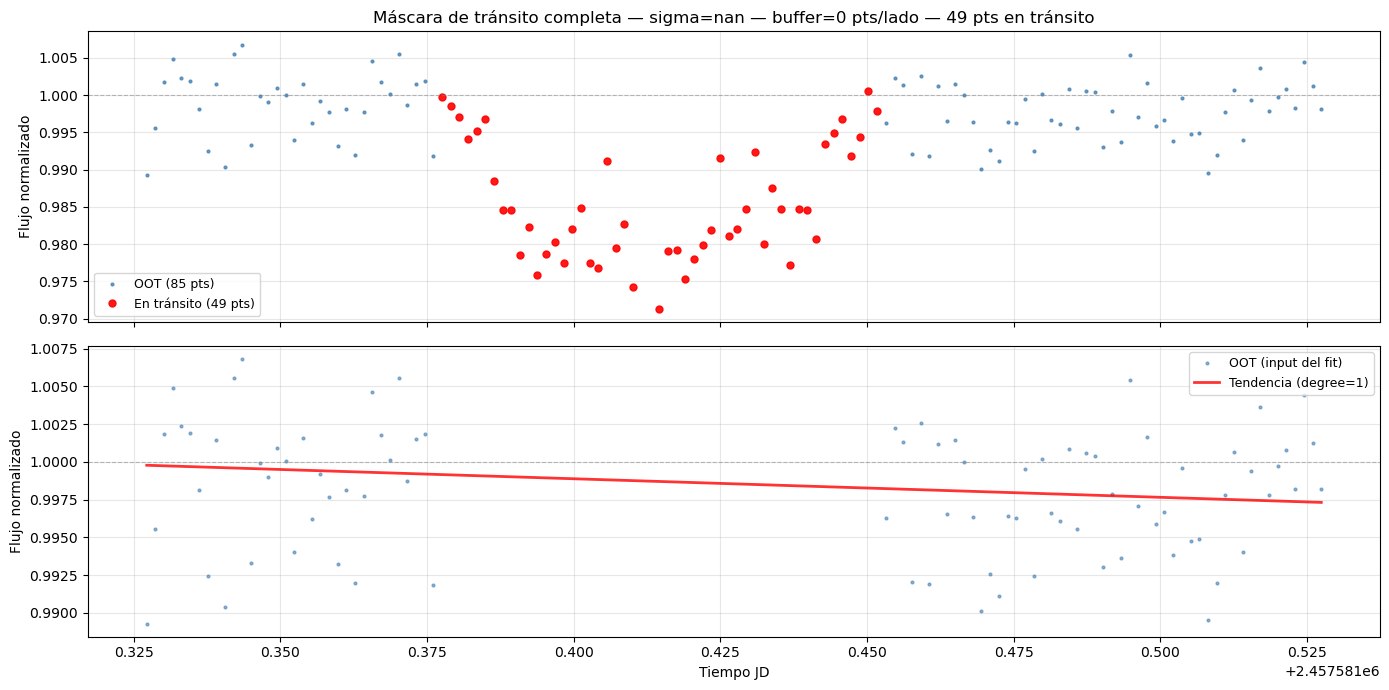

Puntos en tránsito : 49 (36.6%)
Puntos OOT : 85 (63.4%)
Total : 134

✓ Fracción de tránsito razonable.
 → Si la tendencia (rojo) sigue una línea suave SIN bajar en el tránsito, el detrending es seguro.


In [13]:
# Permite verificar si el polinomio realmente solo ve puntos OOT
time_col_diag = 'time_jd' if 'time_jd' in lc_norm.columns and lc_norm['time_jd'].notna().any() else 'frame_index'
in_transit = lc_norm['in_transit_mask'].astype(bool)
oot = ~in_transit

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel superior: máscara sobre flujo normalizado
axes[0].plot(lc_norm.loc[oot, time_col_diag], lc_norm.loc[oot, 'normalized_flux'],
'.', color='steelblue', ms=4, alpha=0.8, label=f'OOT ({oot.sum()} pts)')
axes[0].plot(lc_norm.loc[in_transit, time_col_diag], lc_norm.loc[in_transit, 'normalized_flux'],
'o', color='red', ms=5, alpha=0.9, label=f'En tránsito ({in_transit.sum()} pts)')
axes[0].axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[0].set_ylabel('Flujo normalizado')
axes[0].set_title(
    f"Máscara de tránsito completa — sigma={best_payload['sigma_threshold']} — "
    f"buffer={best_payload.get('window_buffer_points', 0)} pts/lado — "
    f"{in_transit.sum()} pts en tránsito"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel inferior: tendencia sobre los puntos OOT
axes[1].plot(lc_norm.loc[oot, time_col_diag], lc_norm.loc[oot, 'normalized_flux'],
'.', color='steelblue', ms=4, alpha=0.6, label='OOT (input del fit)')
axes[1].plot(lc_detrended[time_col_diag], lc_detrended['trend'],
'-', color='red', lw=2, alpha=0.8, label=f"Tendencia (degree={best_payload['degree']})")
axes[1].axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.5)
axes[1].set_ylabel('Flujo normalizado')
axes[1].set_xlabel('Tiempo JD' if time_col_diag == 'time_jd' else 'Índice de frame')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de la máscara
n_transit = int(in_transit.sum())
n_oot = int(oot.sum())
n_total = len(lc_norm)
transit_fraction = n_transit / n_total * 100.0
print(f"Puntos en tránsito : {n_transit} ({transit_fraction:.1f}%)")
print(f"Puntos OOT : {n_oot} ({100-transit_fraction:.1f}%)")
print(f"Total : {n_total}")
print()
if transit_fraction < 5.0:
    print("⚠ ALERTA: Muy pocos puntos marcados como tránsito. La máscara puede ser insuficiente.")
    print(" → Aumenta window_buffer_points y/o reduce sigma_threshold para cubrir ingreso y egreso.")
elif transit_fraction > 50.0:
    print("⚠ ALERTA: Demasiados puntos marcados como tránsito. La máscara puede ser demasiado agresiva.")
    print(" → Reduce window_buffer_points y/o sube sigma_threshold para no perder demasiado OOT.")
else:
    print("✓ Fracción de tránsito razonable.")
    print(" → Si la tendencia (rojo) sigue una línea suave SIN bajar en el tránsito, el detrending es seguro.")

## 7 · Visualización: antes vs. después de normalización + detrending

Comparativa de tres versiones de la curva de luz para evaluar mejoría de la fotometría.

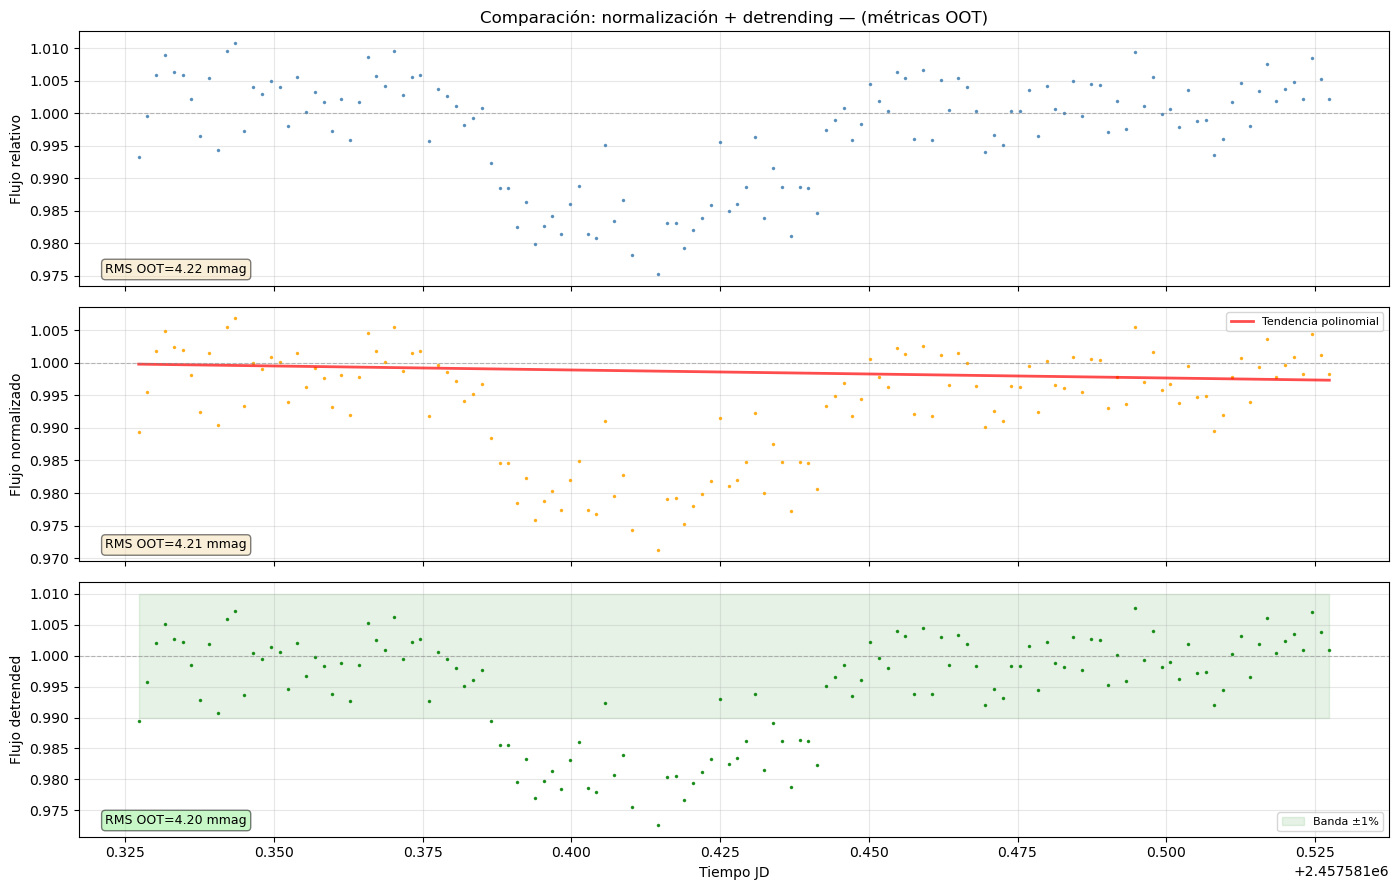

Resumen (solo OOT):
  RMS OOT original   : 4.224 mmag
  RMS OOT normalizado: 4.207 mmag
  RMS OOT detrended  : 4.200 mmag


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

time_col = 'time_jd' if 'time_jd' in lc_detrended.columns and lc_detrended['time_jd'].notna().any() else 'frame_index'
x_label  = 'Tiempo JD' if time_col == 'time_jd' else 'Índice de frame'

oot_mask = ~lc_detrended['in_transit_mask'].astype(bool)
resid_orig_oot = (lc_detrended.loc[oot_mask, 'relative_flux'] - 1.0).to_numpy(dtype=float)
resid_norm_oot = (lc_detrended.loc[oot_mask, 'normalized_flux'] - 1.0).to_numpy(dtype=float)
resid_det_oot  = (lc_detrended.loc[oot_mask, 'detrended_flux'] - 1.0).to_numpy(dtype=float)

rms_orig_oot = float(np.std(resid_orig_oot, ddof=1)) * 1000.0
rms_norm_oot = float(np.std(resid_norm_oot, ddof=1)) * 1000.0
rms_det_oot  = float(np.std(resid_det_oot, ddof=1)) * 1000.0

# Panel 1: Flujo relativo original (métricas OOT)
axes[0].plot(lc_detrended[time_col], lc_detrended['relative_flux'], '.', color='steelblue', ms=3, alpha=0.8)
axes[0].axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel('Flujo relativo')
axes[0].set_title(f'Comparación: normalización + detrending — (métricas OOT)')
axes[0].grid(True, alpha=0.3)
axes[0].text(
    0.02,
    0.05,
    f"RMS OOT={rms_orig_oot:.2f} mmag",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Panel 2: Flujo normalizado (sin detrending aún)
axes[1].plot(lc_detrended[time_col], lc_detrended['normalized_flux'], '.', color='orange', ms=3, alpha=0.8)
axes[1].plot(lc_detrended[time_col], lc_detrended['trend'], '-', color='red', lw=2, alpha=0.7, label='Tendencia polinomial')
axes[1].axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_ylabel('Flujo normalizado')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
axes[1].text(
    0.02,
    0.05,
    f"RMS OOT={rms_norm_oot:.2f} mmag",
    transform=axes[1].transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

# Panel 3: Flujo detrended (final)
axes[2].plot(lc_detrended[time_col], lc_detrended['detrended_flux'], '.', color='green', ms=3, alpha=0.8)
axes[2].axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
axes[2].fill_between(lc_detrended[time_col], 0.99, 1.01, alpha=0.1, color='green', label='Banda ±1%')
axes[2].set_ylabel('Flujo detrended')
axes[2].set_xlabel(x_label)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)
axes[2].text(
    0.02,
    0.05,
    f"RMS OOT={rms_det_oot:.2f} mmag",
    transform=axes[2].transAxes,
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
)

plt.tight_layout()
plt.show()

print('Resumen (solo OOT):')
print(f'  RMS OOT original   : {rms_orig_oot:.3f} mmag')
print(f'  RMS OOT normalizado: {rms_norm_oot:.3f} mmag')
print(f'  RMS OOT detrended  : {rms_det_oot:.3f} mmag')

## 7b · Filtrado de outliers OOT (>3σ)

Filtra automáticamente los puntos OOT que se desvían más de 3σ del nivel OOT. Se muestra el RMS OOT antes y después del filtrado, y se visualizan los outliers en la curva.

RMS OOT antes del filtrado:   4.200 mmag
RMS OOT tras excluir outliers: 4.200 mmag
Outliers OOT detectados (>3σ): 0


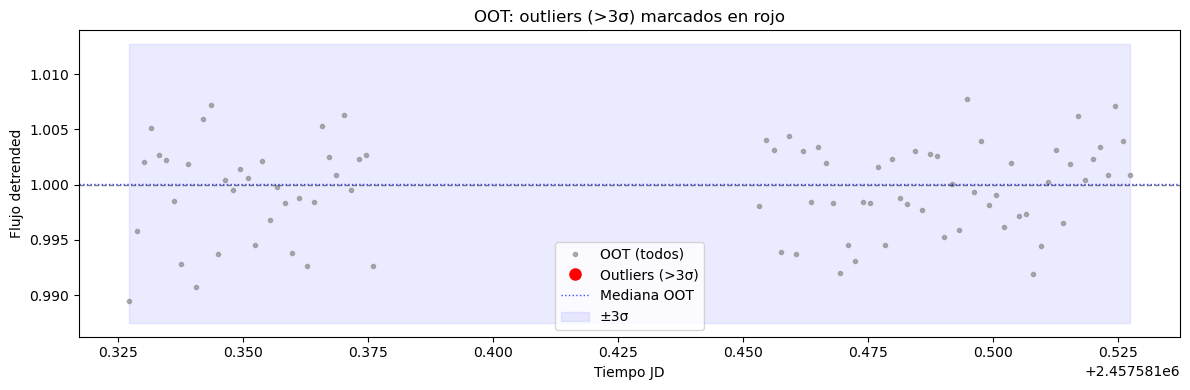

In [15]:
# --- Filtrado de outliers OOT (>3σ) ---
oot_mask = ~lc_detrended['in_transit_mask'].astype(bool)
oot_flux = lc_detrended.loc[oot_mask, 'detrended_flux']
oot_time = lc_detrended.loc[oot_mask, time_col] if 'time_col' in locals() else lc_detrended.loc[oot_mask, 'frame_index']
oot_resid = oot_flux - 1.0
rms_oot_pre = float(np.std(oot_resid, ddof=1)) * 1000.0
med_oot = np.median(oot_flux)
std_oot = np.std(oot_flux, ddof=1)
outlier_mask = np.abs(oot_flux - med_oot) > 3 * std_oot
n_outliers = int(outlier_mask.sum())

# Excluir outliers
oot_flux_clipped = oot_flux[~outlier_mask]
rms_oot_post = float(np.std(oot_flux_clipped - 1.0, ddof=1)) * 1000.0

print(f'RMS OOT antes del filtrado:   {rms_oot_pre:.3f} mmag')
print(f'RMS OOT tras excluir outliers: {rms_oot_post:.3f} mmag')
print(f'Outliers OOT detectados (>3σ): {n_outliers}')

# Visualización
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(oot_time, oot_flux, '.', color='gray', alpha=0.6, label='OOT (todos)')
ax.plot(oot_time[outlier_mask], oot_flux[outlier_mask], 'o', color='red', ms=8, label='Outliers (>3σ)')
ax.axhline(1.0, color='k', lw=1, ls='--', alpha=0.5)
ax.axhline(med_oot, color='blue', lw=1, ls=':', alpha=0.7, label='Mediana OOT')
ax.fill_between(oot_time, med_oot-3*std_oot, med_oot+3*std_oot, color='blue', alpha=0.08, label='±3σ')
ax.set_ylabel('Flujo detrended')
ax.set_xlabel(x_label)
ax.set_title('OOT: outliers (>3σ) marcados en rojo')
ax.legend()
plt.tight_layout()
plt.show()

## 8 · Diagnóstico: flujo por comparadora

Comprueba que las comparadoras son estables entre sí. Una comparadora variable se detecta
porque su flujo individual no sigue el mismo patrón que el resto.

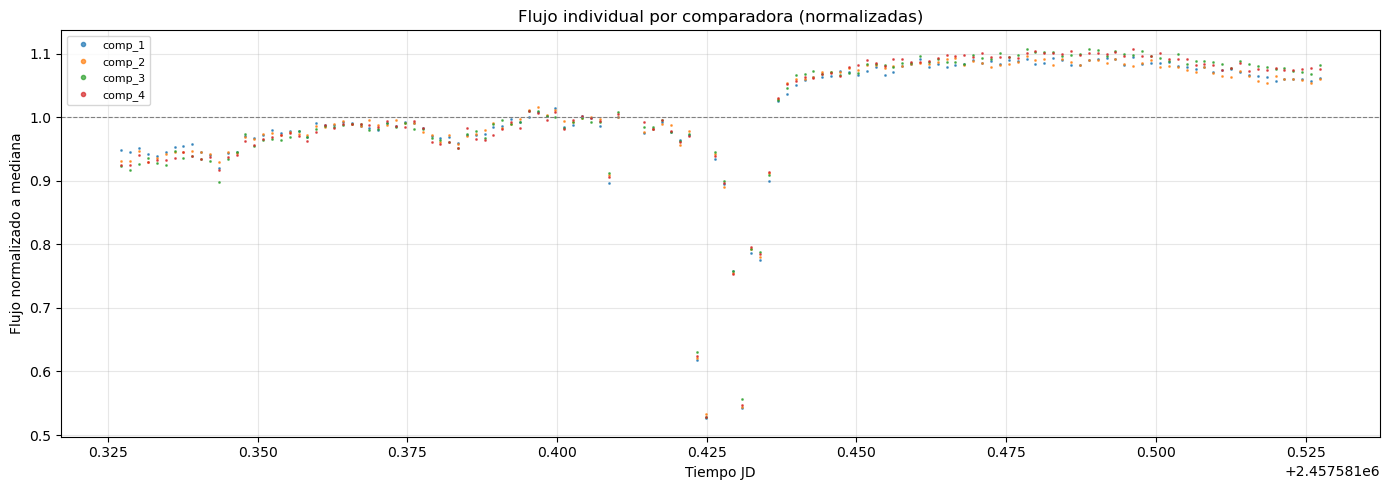

In [16]:
ap = pd.read_csv(PHOT_DIR / 'aperture_photometry.csv')
comp_data = ap[ap['role'] == 'comparison'].copy()

fig, ax = plt.subplots(figsize=(14, 5))
for source_id, group in comp_data.groupby('source_id'):
    norm_flux = group['net_flux'] / group['net_flux'].median()
    x_vals = group['time_jd'] if 'time_jd' in group.columns and group['time_jd'].notna().any() else group['frame_index']
    ax.plot(x_vals, norm_flux, '.', ms=2, alpha=0.7, label=source_id)

ax.axhline(1.0, color='gray', lw=0.8, linestyle='--')
ax.set_ylabel('Flujo normalizado a mediana')
ax.set_xlabel(x_label)
ax.set_title('Flujo individual por comparadora (normalizadas)')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

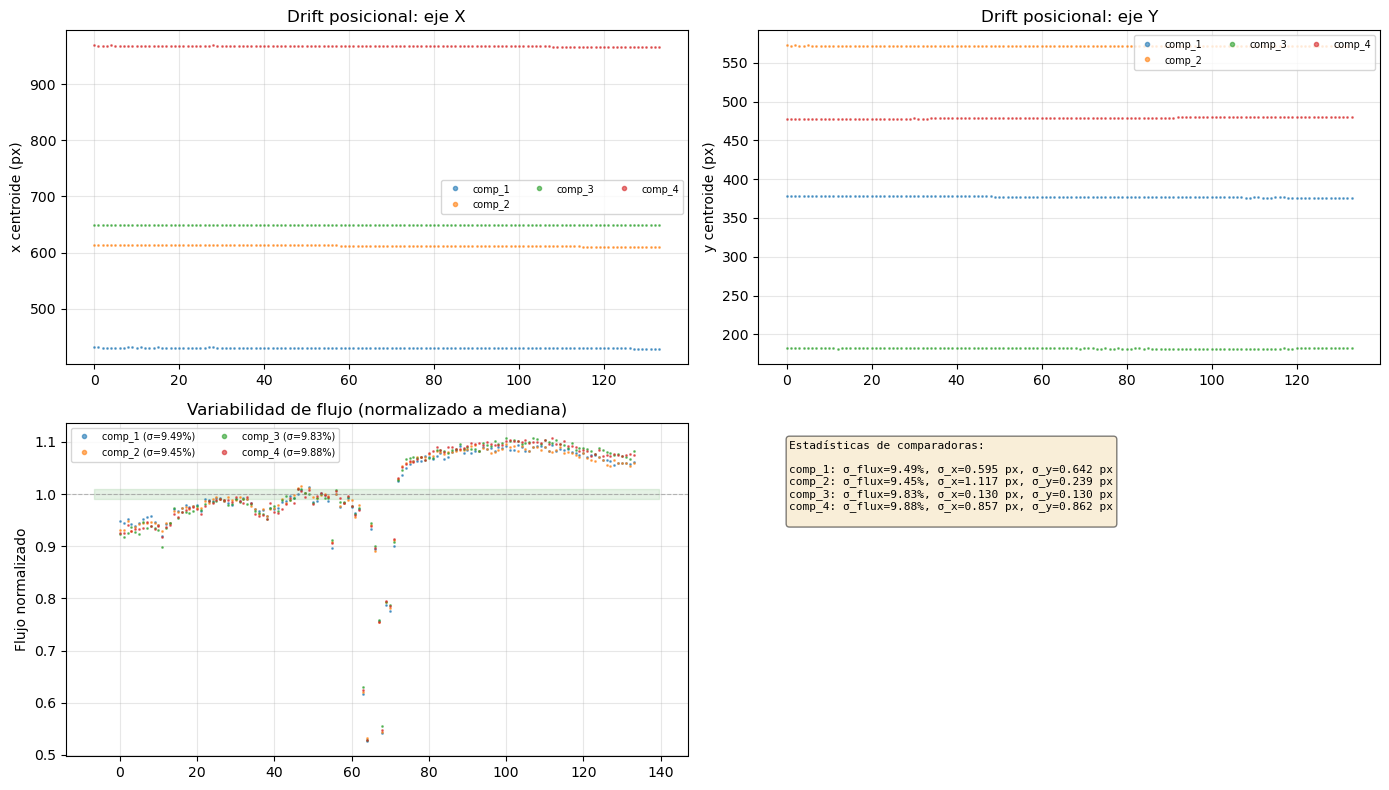

EVALUACIÓN DE ESTABILIDAD DE COMPARADORAS

comp_1: ⚠ ALERTA
  Variabilidad flujo: 9.49% [MALO >3%]
  Drift posicional:   0.875 px (σ_x=0.595, σ_y=0.642) [OK <2px]

comp_2: ⚠ ALERTA
  Variabilidad flujo: 9.45% [MALO >3%]
  Drift posicional:   1.142 px (σ_x=1.117, σ_y=0.239) [OK <2px]

comp_3: ⚠ ALERTA
  Variabilidad flujo: 9.83% [MALO >3%]
  Drift posicional:   0.184 px (σ_x=0.130, σ_y=0.130) [BUENO <0.5px]

comp_4: ⚠ ALERTA
  Variabilidad flujo: 9.88% [MALO >3%]
  Drift posicional:   1.215 px (σ_x=0.857, σ_y=0.862) [OK <2px]

→ Si alguna comparadora tiene variabilidad >3% o drift >2 px, considéralas candidatas a exclusión.


In [17]:

# --- Análisis de estabilidad de comparadoras ---
# Comprueba drift de posición y variabilidad de flujo

ap_all = pd.read_csv(PHOT_DIR / 'aperture_photometry.csv')
comparisons = ap_all[ap_all['role'] == 'comparison'].copy()

# Agrupar por comparadora y analizar
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: Drift en x
ax = axes[0, 0]
for source_id, group in comparisons.groupby('source_id'):
    ax.plot(group['frame_index'], group['x'], '.', ms=2, alpha=0.6, label=source_id)
ax.set_ylabel('x centroide (px)')
ax.set_title('Drift posicional: eje X')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, markerscale=3, ncol=3)

# Panel 2: Drift en y
ax = axes[0, 1]
for source_id, group in comparisons.groupby('source_id'):
    ax.plot(group['frame_index'], group['y'], '.', ms=2, alpha=0.6, label=source_id)
ax.set_ylabel('y centroide (px)')
ax.set_title('Drift posicional: eje Y')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, markerscale=3, ncol=3)

# Panel 3: Variabilidad de flujo
ax = axes[1, 0]
for source_id, group in comparisons.groupby('source_id'):
    flux_norm = group['net_flux'] / group['net_flux'].median()
    sigma_flux = float(np.std(flux_norm, ddof=1)) * 100.0  # en %
    ax.plot(group['frame_index'], flux_norm, '.', ms=2, alpha=0.6, label=f'{source_id} (σ={sigma_flux:.2f}%)')
ax.axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax.fill_between(ax.get_xlim(), 0.99, 1.01, color='green', alpha=0.1)
ax.set_ylabel('Flujo normalizado')
ax.set_title('Variabilidad de flujo (normalizado a mediana)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, markerscale=3, ncol=2)

# Panel 4: Estadísticas
ax = axes[1, 1]
ax.axis('off')

stats_text = "Estadísticas de comparadoras:\n\n"
for source_id, group in comparisons.groupby('source_id'):
    flux = group['net_flux'].values
    flux_norm = flux / np.median(flux)
    sigma_pct = np.std(flux_norm, ddof=1) * 100.0
    dx_px = np.std(group['x'], ddof=1)
    dy_px = np.std(group['y'], ddof=1)
    stats_text += f"{source_id}: σ_flux={sigma_pct:.2f}%, σ_x={dx_px:.3f} px, σ_y={dy_px:.3f} px\n"

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Resumen de calidad
print("=" * 70)
print("EVALUACIÓN DE ESTABILIDAD DE COMPARADORAS")
print("=" * 70)
for source_id, group in comparisons.groupby('source_id'):
    flux = group['net_flux'].values
    flux_norm = flux / np.median(flux)
    sigma_pct = np.std(flux_norm, ddof=1) * 100.0
    dx_px = np.std(group['x'], ddof=1)
    dy_px = np.std(group['y'], ddof=1)
    drift_total = np.sqrt(dx_px**2 + dy_px**2)
    
    quality = "✓ OK" if sigma_pct < 3.0 and drift_total < 2.0 else "⚠ ALERTA"
    print(f"\n{source_id}: {quality}")
    print(f"  Variabilidad flujo: {sigma_pct:.2f}% {'[BUENO <1%]' if sigma_pct < 1.0 else '[OK <3%]' if sigma_pct < 3.0 else '[MALO >3%]'}")
    print(f"  Drift posicional:   {drift_total:.3f} px (σ_x={dx_px:.3f}, σ_y={dy_px:.3f}) {'[BUENO <0.5px]' if drift_total < 0.5 else '[OK <2px]' if drift_total < 2.0 else '[MALO >2px]'}")

print("\n→ Si alguna comparadora tiene variabilidad >3% o drift >2 px, considéralas candidatas a exclusión.")


## 9 · Máscara de tránsito (10%/90%) y RMS OOT

Calcula la máscara con `estimate_transit_mask`, la muestra sobre la curva normalizada
y reporta el RMS OOT para validar rápidamente la calidad antes del ajuste final.

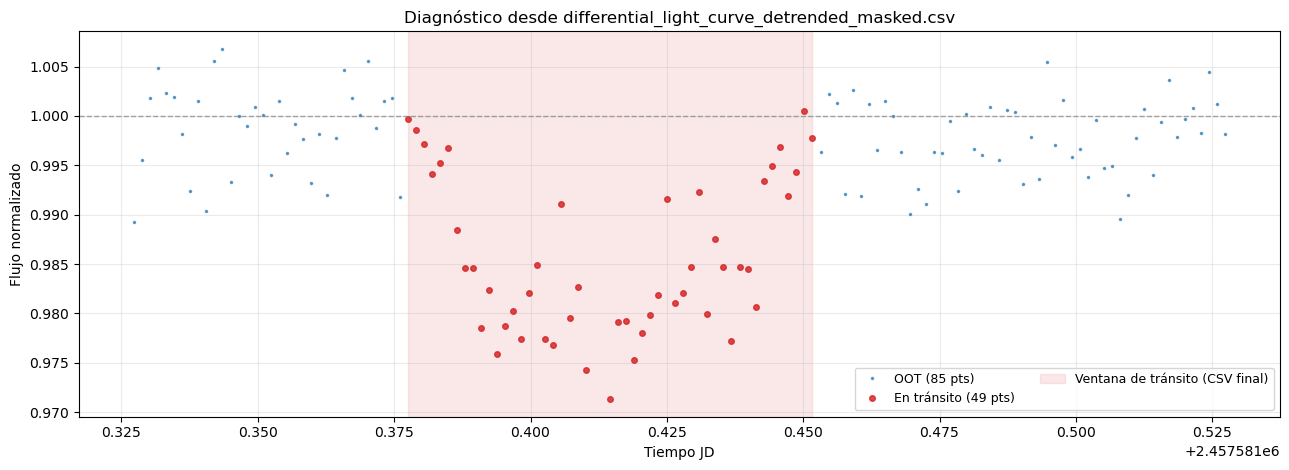

=== Resumen desde CSV final ===
Archivo                 : differential_light_curve_detrended_masked.csv
Inicio/fin máscara      : 2457581.37755787 / 2457581.45170139
Puntos en tránsito/OOT  : 49 / 85
RMS OOT                 : 4.207 mmag (normalized_flux)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Diagnóstico directo desde el producto final (sin recalcular máscara ni detrending)
final_path = PHOT_DIR / 'differential_light_curve_detrended_masked.csv'
lc_final = pd.read_csv(final_path).copy()

required_cols = ['normalized_flux', 'in_transit_mask']
missing_cols = [c for c in required_cols if c not in lc_final.columns]
if missing_cols:
    raise ValueError(f'Faltan columnas en {final_path.name}: {missing_cols}')

time_col_final = 'time_jd' if 'time_jd' in lc_final.columns and lc_final['time_jd'].notna().any() else 'frame_index'
x_label_final = 'Tiempo JD' if time_col_final == 'time_jd' else 'Índice de frame'

transit_mask = lc_final['in_transit_mask'].astype(bool).to_numpy()
oot_mask = ~transit_mask

if transit_mask.any():
    idx = np.where(transit_mask)[0]
    t_start = float(lc_final.loc[idx[0], time_col_final])
    t_end = float(lc_final.loc[idx[-1], time_col_final])
else:
    raise RuntimeError('La máscara in_transit_mask está vacía en el CSV final.')

resid_oot = (lc_final.loc[oot_mask, 'normalized_flux'] - 1.0).to_numpy(dtype=float)
rms_oot_mmag = float(np.std(resid_oot, ddof=1) * 1000.0) if oot_mask.sum() > 1 else np.nan

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(
    lc_final.loc[oot_mask, time_col_final],
    lc_final.loc[oot_mask, 'normalized_flux'],
    '.', ms=3, alpha=0.65, color='tab:blue', label=f'OOT ({int(oot_mask.sum())} pts)'
)
ax.plot(
    lc_final.loc[transit_mask, time_col_final],
    lc_final.loc[transit_mask, 'normalized_flux'],
    'o', ms=4, alpha=0.85, color='tab:red', label=f'En tránsito ({int(transit_mask.sum())} pts)'
)

ax.axhline(1.0, ls='--', lw=1.0, color='gray', alpha=0.7)
ax.axvspan(t_start, t_end, color='tab:red', alpha=0.10, label='Ventana de tránsito (CSV final)')

ax.set_title('Diagnóstico desde differential_light_curve_detrended_masked.csv')
ax.set_xlabel(x_label_final)
ax.set_ylabel('Flujo normalizado')
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

print('=== Resumen desde CSV final ===')
print(f'Archivo                 : {final_path.name}')
print(f'Inicio/fin máscara      : {t_start:.8f} / {t_end:.8f}')
print(f'Puntos en tránsito/OOT  : {int(transit_mask.sum())} / {int(oot_mask.sum())}')
print(f'RMS OOT                 : {rms_oot_mmag:.3f} mmag (normalized_flux)')

In [ ]:
# Comparación del MID POINT (centro del tránsito) detectado vs literatura (Qatar-1b)
import numpy as np
import pandas as pd

# Cargar la curva final (ya contiene la máscara de tránsito)
lc = pd.read_csv(PHOT_DIR / 'differential_light_curve_detrended_masked.csv')
transit_mask = lc['in_transit_mask'].values.astype(bool)
time_jd = lc['time_jd'].values
flux = lc['normalized_flux'].values if 'normalized_flux' in lc.columns else lc['flux'].values

# Calcular el mid point detectado
if np.any(transit_mask):
    idx_start = np.argmax(transit_mask)
    idx_end = len(transit_mask) - 1 - np.argmax(transit_mask[::-1])
    t_mid_jd = (time_jd[idx_start] + time_jd[idx_end]) / 2
    duracion_horas = (time_jd[idx_end] - time_jd[idx_start]) * 24
    depth = 1 - np.median(flux[transit_mask])
    depth_mmag = depth * 1000  # profundidad en milimagnitudes
else:
    t_mid_jd = np.nan
    duracion_horas = np.nan
    depth = np.nan
    depth_mmag = np.nan

# Valor de la literatura para el mid point (T0)
T0_literatura = 2455799.57954  # Actualiza si es necesario

# Diferencia en minutos
min_diff_mid = (t_mid_jd - T0_literatura) * 24 * 60
"""
print(f"MID POINT detectado: JD = {t_mid_jd:.5f}")
print(f"MID POINT literatura (T0): JD = {T0_literatura:.5f}")
print(f"Diferencia mid point:      {min_diff_mid:.2f} minutos\n")
"""
print(f"Duración del tránsito detectado: {duracion_horas:.3f} horas")
print(f"Profundidad (depth) detectada:   {depth:.5f} ({depth_mmag:.1f} mmag)")

MID POINT detectado: JD = 2457581.41463
MID POINT literatura (T0): JD = 2455799.57954
Diferencia mid point:      2565842.53 minutos

Duración del tránsito detectado: 1.779 horas
Profundidad (depth) detectada:   0.01545 (15.5 mmag)
